In [3]:
# https://scores.readthedocs.io/en/stable/tutorials/Fractions_Skill_Score.html

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pathlib import Path
from datetime import datetime
import re
import pandas as pd
from scores.spatial import fss_2d

from dask.distributed import Client, wait
import os, sys
import psutil

sys.path.append('/home/548/cd3022/repos/Irradiance-comparisons/Irradiance-comparisons')
import logger
from read_datasets import read_dataset

LOG = logger.get_logger(__name__)

In [2]:
client = Client(
    n_workers=24,
    threads_per_worker=1
)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 24
Total threads: 24,Total memory: 95.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42833,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35927,Total threads: 1
Dashboard: /proxy/44079/status,Memory: 3.96 GiB
Nanny: tcp://127.0.0.1:37729,


In [3]:
# ds_ct = xr.open_zarr("/g/data/su28/himawari-ahi/cloud/ct/aus_regional_domain/S_NWC_CT_HIMA08_HIMA-N-NR.zarr/")

# lat=slice(-10, -44.5)
# lon=slice(112, 156.26)
# ds_ct = ds_ct.sel(
#     lat=lat,
#     lon=lon,
# )

In [4]:
path = Path('/g/data/rv74/satellite-products/arc/der/himawari-ahi/solar/p1s/latest/2020/01/01')
files = [f for f in path.glob('*.nc')]

ds_sol = xr.open_mfdataset(
    files,
    chunks='auto',
    concat_dim='time',
    combine='nested',
    data_vars='minimal',
    coords='minimal',
    compat='override',
    parallel=True,
)

In [5]:
# BARRA Cloud Types
BARRA = Path('/g/data/ob53/BARRA2/output/reanalysis/')
BARRA_R2 = BARRA / "AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1"
BARRA_R2_DIR = BARRA_R2 / "1hr"

def _preprocess(ds):
    return ds.sel(lat=slice(-44.5, -10), lon=slice(112, 156.26)) #, time=slice('2016', '2024'))


files = sorted([f for f in BARRA_R2_DIR.glob('clt/latest/*1hr_2020*.nc')])
bar = xr.open_mfdataset(
    files,
    chunks='auto',
    concat_dim='time',
    combine='nested',
    data_vars='minimal',
    coords='minimal',
    compat='override',
    parallel=True,
    preprocess=_preprocess
)

In [6]:
bar = bar.sel(time='2020-01-01')
# ds_sol = ds_sol.sel(time=bar.time)

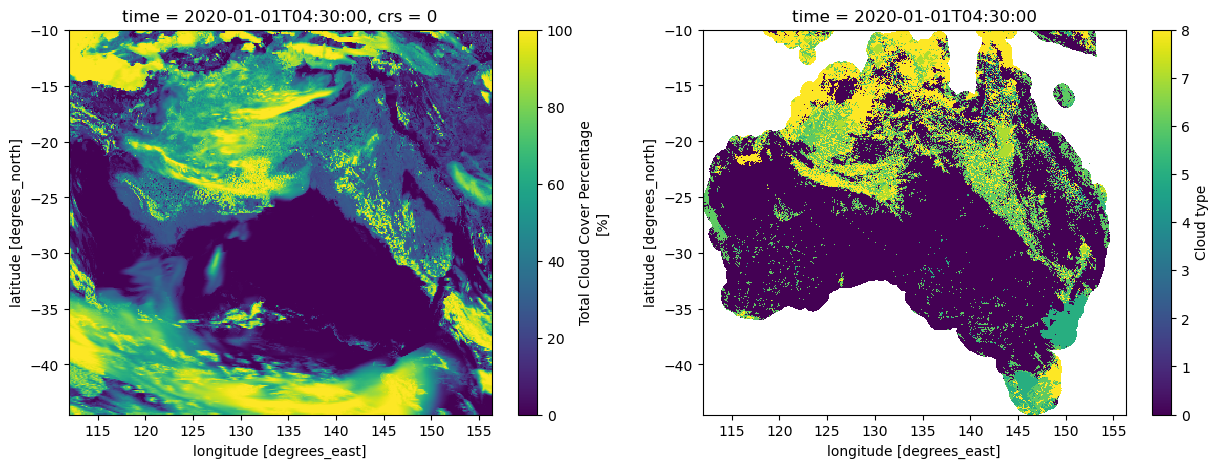

In [11]:
time = '2020-01-01T04:30:00.000000000'
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
bar.sel(time=time).clt.plot(ax=ax[0])
ds_sol.sel(time=time,).cloud_type.plot(ax=ax[1])

# Group Cloud Types for FSS

In [19]:
ds_sol = ds_sol.reindex(time=bar.time)
clt_obs = xr.where(ds_sol.cloud_type > 0, 100, 0)
clt_obs = clt_obs.interp(
    latitude=bar.lat,
    longitude=bar.lon,
    method='linear'
)

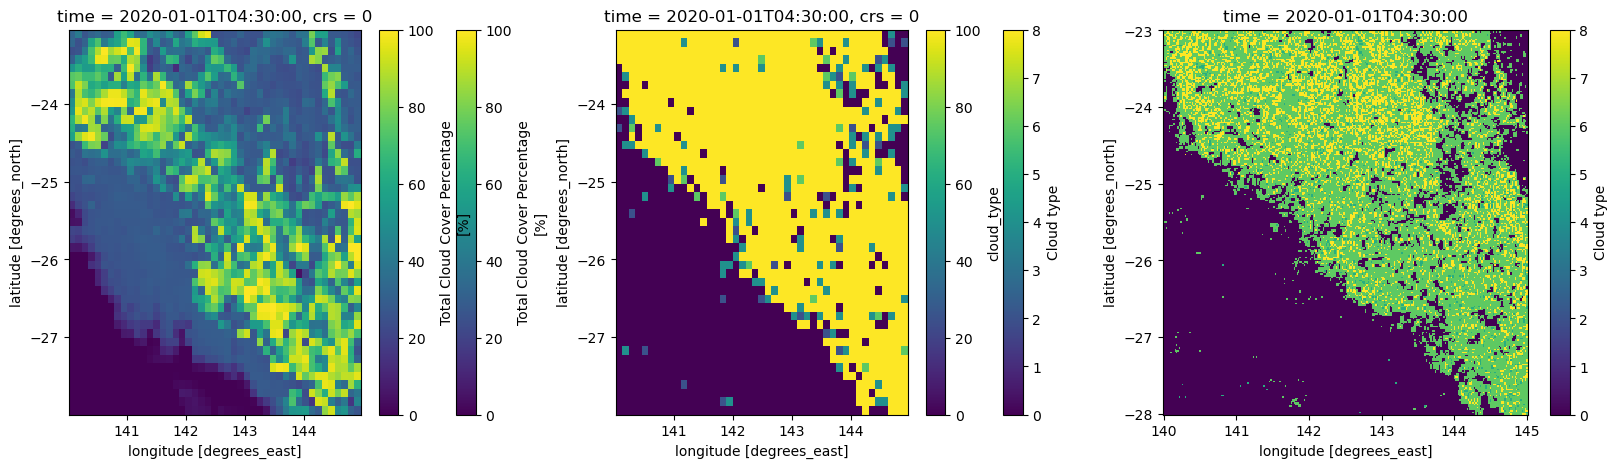

In [20]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))
bar.sel(time=time).clt.plot(ax=ax[0])
ds_sol.sel(time=time,).cloud_type.plot(ax=ax[1])

bar.clt.sel(
    time=time,
    lat=slice(-28, -23),
    lon=slice(140, 145)
).plot(ax=ax[0])

clt_obs.sel(
    time=time,
    lat=slice(-28, -23),
    lon=slice(140, 145)
).plot(ax=ax[1])

ds_sol.cloud_type.sel(
    time=time,
    latitude=slice(-28, -23),
    longitude=slice(140, 145)
).plot(ax=ax[2])

# Apply FSS

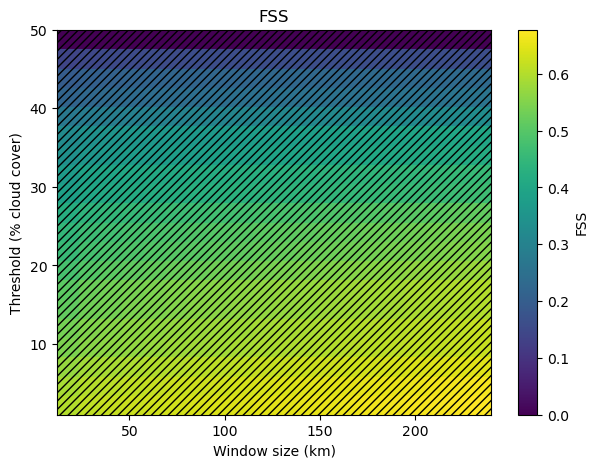

In [28]:
daily_mean = True

obs = clt_obs
fcst = bar.clt

if daily_mean:
    obs = obs.mean(dim='time')
    fcst = fcst.mean(dim='time')

# def drop_duplicate_times(da):
#     _, index = np.unique(da['time'], return_index=True)
#     return da.isel(time=index)

# obs = drop_duplicate_times(obs)
# fcst = drop_duplicate_times(fcst)

obs, fcst = xr.align(obs, fcst)

obs = obs.compute()
fcst = fcst.compute()

thresholds = np.linspace(1, 50, 20)
window_sizes = np.arange(1, 21)

# Empty array to store results
fss_results = np.zeros((len(thresholds), len(window_sizes)))
L_vals = np.zeros(len(thresholds))

for i, thr in enumerate(thresholds):
    f = xr.where(obs > thr, 1, 0).sum().item() / obs.size
    L = 0.5 + f/2
    L_vals[i] = L
    for j, win in enumerate(window_sizes):
        fss = fss_2d(
            fcst,
            obs,
            event_threshold=thr,
            window_size=(win, win),
            spatial_dims=["lat", "lon"],
        )
        # Extract a scalar if needed
        # if isinstance(fss, xr.DataArray):
        #     fss = fss.item()
        fss_results[i, j] = fss

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(
    fss_results,
    origin="lower",
    aspect="auto",
    extent=[window_sizes[0]*12, window_sizes[-1]*12, thresholds[0], thresholds[-1]],
    cmap="viridis",
)
cbar = plt.colorbar(im, ax=ax, label="FSS")

ax.set_xlabel("Window size (km)")
ax.set_ylabel("Threshold (% cloud cover)")
ax.set_title("FSS")


# === Overlay hatching for FSS > L for each row ===
# Create coordinate grids matching imshow extent
X, Y = np.meshgrid(window_sizes * 12, thresholds)

# Mask for cells above the row-dependent L
mask = np.zeros_like(fss_results, dtype=bool)
for i in range(len(thresholds)):
    mask[i, :] = fss_results[i, :] < L_vals[i]

# Overlay hatched transparent contour
ax.contourf(
    X,
    Y,
    mask,
    levels=[0.5, 1],
    colors="none",
    hatches=["////"],
    alpha=0,
)


plt.show()